## Imports & Global Settings

In [1]:
import numpy as np
import pandas as pd
import random
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns
import shap

np.random.seed(42)
random.seed(42)

## Dataset Selection & Loading

In [2]:
DATASET_NAME = "cicddos2019"

DATASET_PATHS = {
    "cicids2017": "cicids2017.csv",
    "cicids2018": "cicids2018.csv",
    "cicddos2019": "cicddos2019.csv"
}

df = pd.read_csv(DATASET_PATHS[DATASET_NAME])
print("Dataset:", DATASET_NAME)
print("Shape:", df.shape)
df.head()

Dataset: cicddos2019
Shape: (50000, 80)


,Unnamed: 0,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Class
0,271174,17,449,98,0,42832.0,0.0,440.0,296.0,437.06122,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_NTP,Attack
1,24038,6,16696066,8,6,48.0,36.0,6.0,6.0,6.00000,...,499965.0,706911.6,999827.0,103.0,7848067.5,1628737.8,8999759.0,6696376.0,Syn,Attack
2,44954,17,3008437,4,0,2064.0,0.0,516.0,516.0,516.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TFTP,Attack
3,53199,17,3112318,4,0,2064.0,0.0,516.0,516.0,516.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TFTP,Attack
4,8940,17,215106,6,0,2088.0,0.0,393.0,321.0,348.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,UDP,Attack


In [3]:
if DATASET_NAME == "cicddos2019":
    df = df.groupby('Label', group_keys=False).apply(
        lambda x: x.sample(
            n=min(len(x), 150_000),
            random_state=42
        )
    )
    print("After stratified sampling:", df.shape)

After stratified sampling: (50000, 80)


## Data Cleaning & Preprocessing

In [4]:
# 1. Remove duplicate rows
df = df.drop_duplicates()

# 2. Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 3. Drop rows with missing values
df.dropna(inplace=True)

# 4. Identify label column (usually 'Label' in CIC datasets)
label_col = 'Label' if 'Label' in df.columns else df.columns[-1]

# 5. Encode labels (Benign = 0, Attack = 1 or multiclass → numeric)
le = LabelEncoder()
df[label_col] = le.fit_transform(df[label_col])

# 6. Split features and target
X = df.drop(columns=[label_col])
y = df[label_col]

# 7. Drop non-numeric columns (e.g., Timestamp)
non_numeric_cols = X.select_dtypes(include=['object']).columns
if len(non_numeric_cols) > 0:
    print("Dropping non-numeric columns:", list(non_numeric_cols))
    X = X.drop(columns=non_numeric_cols)

# 8. Final sanity check
assert X.dtypes.apply(lambda x: np.issubdtype(x, np.number)).all(), \
    "Non-numeric features still present!"

print("Final feature count:", X.shape[1])
print("Class distribution:\n", y.value_counts())

Dropping non-numeric columns: ['Class']
Final feature count: 78
Class distribution:
 Label
4     14128
13    11504
0     11393
12     5697
14     2037
7      1215
15     1045
9       987
3       665
1       440
6       320
8       218
2       141
11       70
10       66
5        58
16        8
17        8
Name: count, dtype: int64


## Train-Test Split (70/30)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(35000, 78) (15000, 78)


## Normalization

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Handle Class Imbalance using SAFE Multiclass SMOTE

In [7]:
if DATASET_NAME == "cicddos2019":
    class_counts = y_train.value_counts()
    majority_count = class_counts.max()

    sampling_strategy = {}

    for cls, count in class_counts.items():
        target = int(0.5 * majority_count)

        # SMOTE must only INCREASE samples
        if count < target:
            sampling_strategy[cls] = target

    print("SMOTE sampling strategy:", sampling_strategy)

    # Only apply SMOTE if there is something to oversample
    if len(sampling_strategy) > 0:
        smote = SMOTE(
            sampling_strategy=sampling_strategy,
            k_neighbors=3,
            random_state=42
        )
        X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
    else:
        X_train_bal, y_train_bal = X_train_scaled, y_train
        print("No SMOTE needed (classes already balanced enough).")

else:
    smote = SMOTE(random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("Class distribution after SMOTE:")
print(pd.Series(y_train_bal).value_counts())
print("After SMOTE shape:", X_train_bal.shape)

SMOTE sampling strategy: {12: 4944, 14: 4944, 7: 4944, 15: 4944, 9: 4944, 3: 4944, 1: 4944, 6: 4944, 8: 4944, 2: 4944, 11: 4944, 10: 4944, 5: 4944, 16: 4944, 17: 4944}
Class distribution after SMOTE:
Label
4     9889
13    8053
0     7975
12    4944
14    4944
3     4944
15    4944
9     4944
1     4944
7     4944
8     4944
6     4944
5     4944
11    4944
10    4944
2     4944
16    4944
17    4944
Name: count, dtype: int64
After SMOTE shape: (100077, 78)


## Feature Selection using FAST PCA (integer components)

In [8]:
pca = PCA(
    n_components=30,          # or 40 if you want
    svd_solver='randomized',
    random_state=42
)

X_train_pca = pca.fit_transform(X_train_bal)
X_test_pca = pca.transform(X_test_scaled)

print("PCA components:", X_train_pca.shape[1])
print("Explained variance ratio:", np.sum(pca.explained_variance_ratio_))

PCA components: 30
Explained variance ratio: 0.9952329469078953


## Model Definition

In [9]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=1000, n_jobs=-1
    ),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

## Train Models & Predict

In [10]:
results = {}
probas = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_pca, y_train_bal)
    print(f"Finished {name}")
    y_pred = model.predict(X_test_pca)
    y_prob = model.predict_proba(X_test_pca)[:, 1] if hasattr(model, "predict_proba") else None

    results[name] = {
      "Accuracy": accuracy_score(y_test, y_pred),
      "Precision": precision_score(y_test, y_pred, average='weighted'),
      "Recall": recall_score(y_test, y_pred, average='weighted'),
      "F1": f1_score(y_test, y_pred, average='weighted'),
      "Confusion": confusion_matrix(y_test, y_pred)
    }

    probas[name] = y_prob

pd.DataFrame(results).T

Training Random Forest...
Finished Random Forest
Training Logistic Regression...
Finished Logistic Regression
Training KNN...
Finished KNN
Training SVM...
Finished SVM
Training Decision Tree...
Finished Decision Tree


,Accuracy,Precision,Recall,F1,Confusion
Random Forest,0.984733,0.98506,0.984733,0.984759,"[[3409, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 6, 0,..."
Logistic Regression,0.973533,0.981411,0.973533,0.976797,"[[3325, 0, 1, 1, 6, 0, 0, 0, 0, 0, 12, 13, 5, ..."
KNN,0.9726,0.976851,0.9726,0.973932,"[[3384, 1, 0, 0, 2, 0, 0, 2, 0, 0, 1, 5, 17, 0..."
SVM,0.969533,0.977782,0.969533,0.973118,"[[3349, 1, 0, 0, 0, 0, 0, 0, 0, 0, 5, 4, 3, 0,..."
Decision Tree,0.9798,0.980186,0.9798,0.979907,"[[3378, 1, 0, 0, 10, 2, 0, 2, 0, 4, 2, 7, 7, 1..."


## Decision Tree Feature Importance

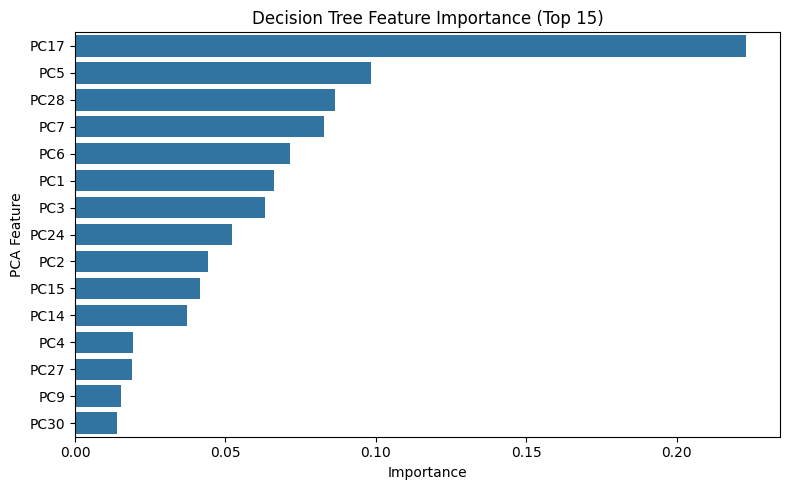

In [11]:
pca_feature_names = [f"PC{i+1}" for i in range(X_train_pca.shape[1])]

dt_model = models.get("Decision Tree")
if hasattr(dt_model, "feature_importances_"):
    importances = pd.Series(dt_model.feature_importances_, index=pca_feature_names)
    importances = importances.sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances.head(15).values, y=importances.head(15).index)
    plt.title("Decision Tree Feature Importance (Top 15)")
    plt.xlabel("Importance")
    plt.ylabel("PCA Feature")
    plt.tight_layout()
    plt.show()
else:
    print("Decision Tree model is not fitted or has no feature_importances_.")

## SHAP Explanations (Other Models)

SHAP for Random Forest


100%|===================| 3594/3600 [02:47<00:00]       

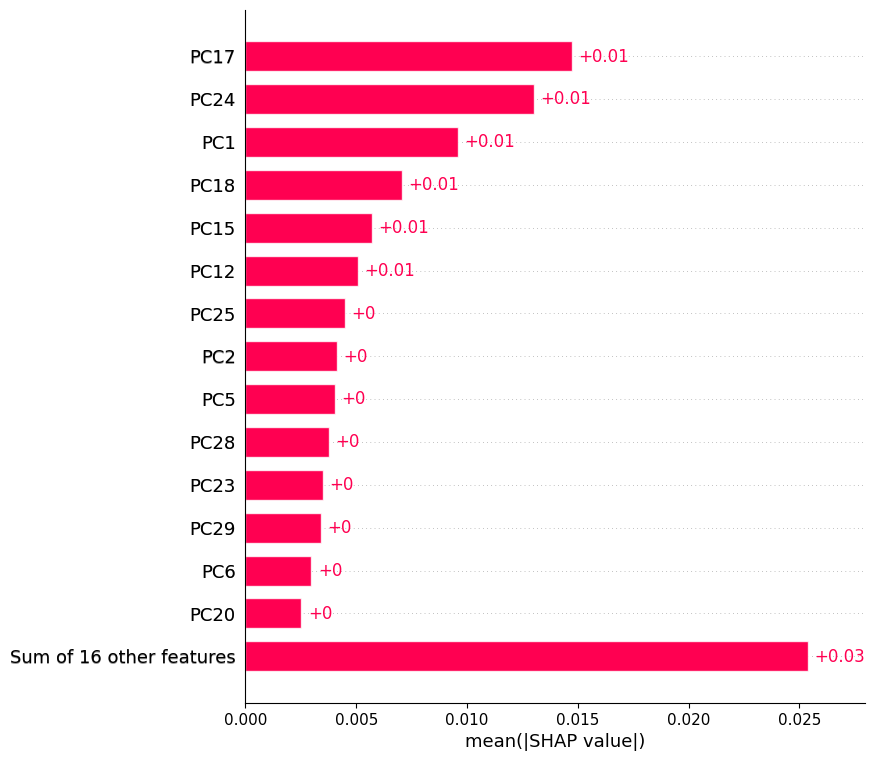

SHAP for Logistic Regression


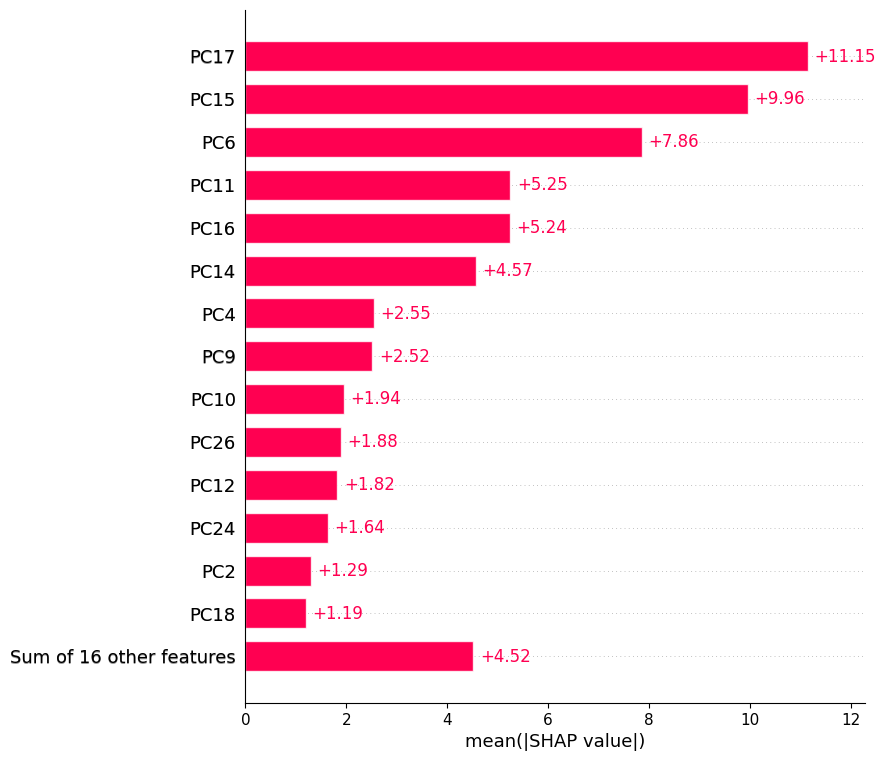

SHAP for KNN
SHAP failed for KNN: The passed model is not callable and cannot be analyzed directly with the given masker! Model: KNeighborsClassifier()
SHAP for SVM
SHAP failed for SVM: The passed model is not callable and cannot be analyzed directly with the given masker! Model: SVC(probability=True, random_state=42)


In [12]:
shap_sample = shap.utils.sample(X_train_pca, 200, random_state=42)

for name, model in models.items():
    if name == "Decision Tree":
        continue
    print(f"SHAP for {name}")
    try:
        explainer = shap.Explainer(model, shap_sample, feature_names=pca_feature_names)
        shap_values = explainer(shap_sample)

        if isinstance(shap_values, list):
            values_to_plot = shap_values[0]
            if len(shap_values) > 1:
                values_to_plot = shap_values[1]
        else:
            if getattr(shap_values, "values", None) is not None and shap_values.values.ndim == 3:
                values_to_plot = shap_values[:, :, 1]
            else:
                values_to_plot = shap_values

        shap.plots.bar(values_to_plot, max_display=15, show=True)
    except Exception as e:
        print(f"SHAP failed for {name}: {e}")

## Confusion Matrices

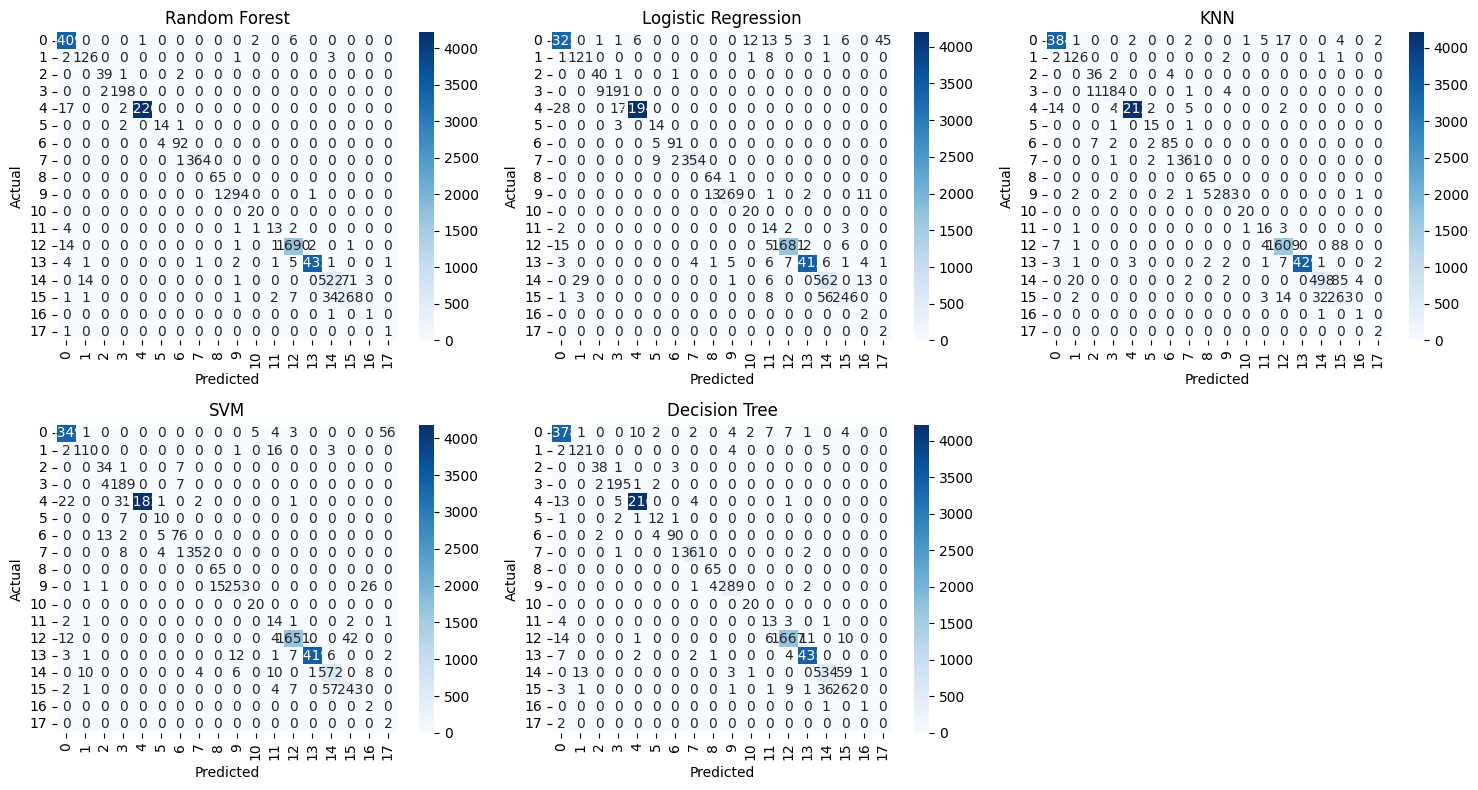

In [13]:
plt.figure(figsize=(15,8))
for i, (name, res) in enumerate(results.items(), 1):
    plt.subplot(2, 3, i)
    sns.heatmap(res["Confusion"], annot=True, fmt='d', cmap='Blues')
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Precision-Recall Curves

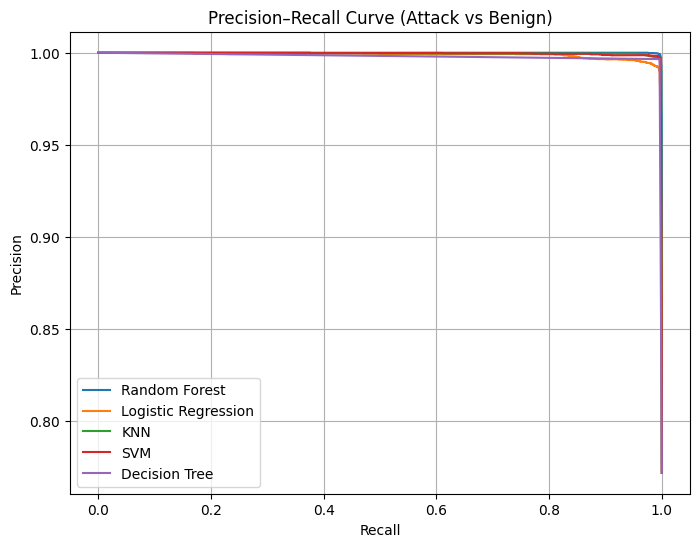

In [14]:
plt.figure(figsize=(8,6))

# Treat all non-zero classes as "Attack"
y_test_binary = (y_test != 0).astype(int)

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_pca)

        # Use max probability among attack classes
        attack_prob = y_prob[:, 1:].max(axis=1)

        precision, recall, _ = precision_recall_curve(y_test_binary, attack_prob)
        plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Attack vs Benign)")
plt.legend()
plt.grid()
plt.show()

## Accuracy Comparison

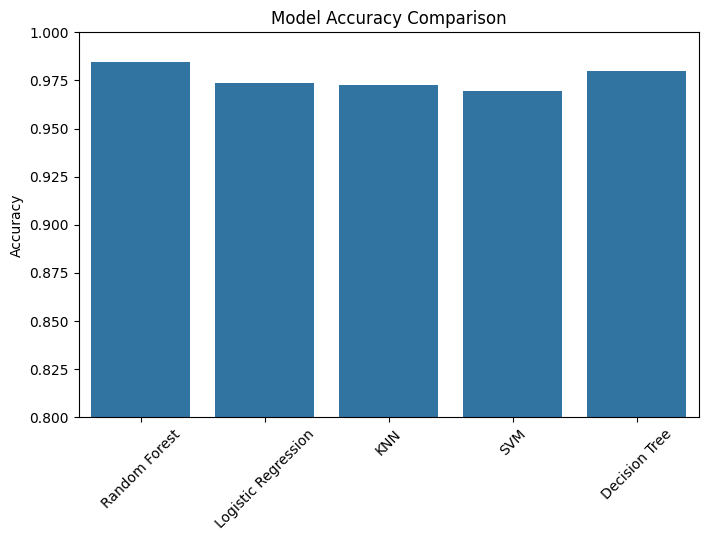

In [15]:
accs = {name: res["Accuracy"] for name, res in results.items()}
plt.figure(figsize=(8,5))
sns.barplot(x=list(accs.keys()), y=list(accs.values()))
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0.8,1.0)
plt.show()